In [4]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn import tree

In [5]:
df=pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df=df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns')
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


In [7]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [11]:
dfne=df[df.Survived==1]
dfne.shape

(342, 5)

In [12]:
median_age=df.Age.median()
median_age

28.0

In [10]:
df['Age'].isnull().sum()

177

In [13]:
df['Age']=df['Age'].fillna(median_age)
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,28.0,23.4500
889,1,1,male,26.0,30.0000


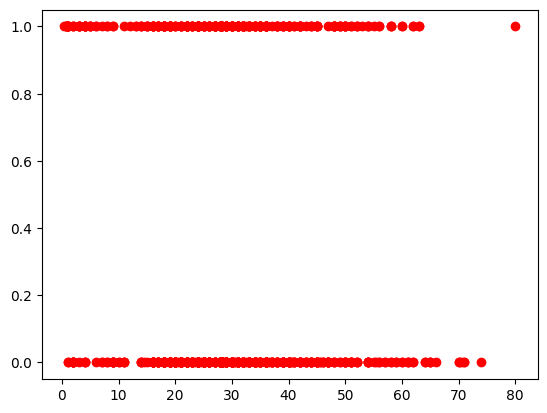

In [14]:
%matplotlib inline
plt.scatter(df.Age,df.Survived,color='red')

In [15]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Sex']=le.fit_transform(df.Sex)

In [18]:
from sklearn.preprocessing import OneHotEncoder 
from sklearn.compose import ColumnTransformer
ct=ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(drop='first'),[2])],
    remainder='passthrough'
)

In [32]:
df['Sex']=ct.fit_transform(df)
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,1.0,22.0,7.2500
1,1,1,0.0,38.0,71.2833
2,1,3,0.0,26.0,7.9250
3,1,1,0.0,35.0,53.1000
4,0,3,1.0,35.0,8.0500


In [33]:
X=df.drop(['Survived'],axis='columns')

In [34]:
y=df['Survived']
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [36]:
model=tree.DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [37]:
model.score(X_test,y_test)

0.8100558659217877

In [ ]:
model.predict([[]])